In [1]:
!pip install hopsworks requests pandas numpy

In [10]:
import os
import time
import requests
import pandas as pd
import numpy as np
from datetime import datetime, timedelta, timezone
import hopsworks

In [3]:
!pip install hopsworks==4.7.* "hopsworks[python]" confluent-kafka

In [11]:
AQICN_TOKEN    = os.getenv("AQICN_TOKEN", "0484c8365b201fb9dfe96619977cc49bddcd30cc")
HOPSWORKS_KEY  = os.getenv("HOPSWORKS_API_KEY", "0A1KDFeOe9vqkggf.pk8y1QNXudPupafCsdKvupwKbEquY2KxRE5cv9Xf5O0DS1o1lIzBm17DwtYfKeZt")
HOPSWORKS_PROJECT = os.getenv("HOPSWORKS_PROJECT", "aqi_predictorrr")
CITY           = "karachi"
BACKFILL_DAYS = 90

In [5]:
def fetch_aqi_data(city: str, token: str) -> dict:
    """Fetch current AQI and pollutant readings for a city."""
    url = f"https://api.waqi.info/feed/{city}/?token={token}"
    response = requests.get(url, timeout=10)
    response.raise_for_status()
    data = response.json()

    if data["status"] != "ok":
        raise ValueError(f"AQICN API error: {data.get('data', 'Unknown error')}")

    return data["data"]

In [6]:
def engineer_features(raw: dict) -> pd.DataFrame:
    """
    Extract and compute features from raw AQICN response.

    Model inputs (features):
      - pollutants: pm25, pm10, o3, no2, so2, co
      - weather:    temperature, humidity, wind speed, pressure
      - time-based: hour, day_of_week, month, is_weekend
      - derived:    aqi_category (encoded)

    Model output (target):
      - aqi: the current AQI value (used as target during training)
    """
    iaqi = raw.get("iaqi", {})
    now  = datetime.now(timezone.utc)

    # --- pollutants (use 0.0 if sensor not available) ---
    pm25    = float(iaqi.get("pm25",  {}).get("v", 0.0))
    pm10    = float(iaqi.get("pm10",  {}).get("v", 0.0))
    o3      = float(iaqi.get("o3",    {}).get("v", 0.0))
    no2     = float(iaqi.get("no2",   {}).get("v", 0.0))
    so2     = float(iaqi.get("so2",   {}).get("v", 0.0))
    co      = float(iaqi.get("co",    {}).get("v", 0.0))

    # --- weather conditions ---
    temperature = float(iaqi.get("t",  {}).get("v", 0.0))
    humidity    = float(iaqi.get("h",  {}).get("v", 0.0))
    wind_speed  = float(iaqi.get("w",  {}).get("v", 0.0))
    pressure    = float(iaqi.get("p",  {}).get("v", 0.0))

    # --- current AQI (this is the TARGET for ML) ---
    aqi = float(raw.get("aqi", 0))

    # --- time-based features ---
    hour        = now.hour
    day_of_week = now.weekday()        # 0=Monday … 6=Sunday
    month       = now.month
    is_weekend  = int(now.weekday() >= 5)

    # --- derived feature: AQI category (0-5 scale) ---
    # Good=0, Moderate=1, Unhealthy for Sensitive=2,
    # Unhealthy=3, Very Unhealthy=4, Hazardous=5
    if aqi <= 50:
        aqi_category = 0
    elif aqi <= 100:
        aqi_category = 1
    elif aqi <= 150:
        aqi_category = 2
    elif aqi <= 200:
        aqi_category = 3
    elif aqi <= 300:
        aqi_category = 4
    else:
        aqi_category = 5

    row = {
        # identifiers
        "timestamp":    now.strftime("%Y-%m-%d %H:%M:%S"),
        "city":         CITY,

        # pollutants
        "pm25":         pm25,
        "pm10":         pm10,
        "o3":           o3,
        "no2":          no2,
        "so2":          so2,
        "co":           co,

        # weather
        "temperature":  temperature,
        "humidity":     humidity,
        "wind_speed":   wind_speed,
        "pressure":     pressure,

        # time features
        "hour":         hour,
        "day_of_week":  day_of_week,
        "month":        month,
        "is_weekend":   is_weekend,

        # derived
        "aqi_category": aqi_category,

        # target
        "aqi":          aqi,
    }

    return pd.DataFrame([row])

In [7]:
def store_features(df: pd.DataFrame):
    """Push the feature row into the Hopsworks Feature Store."""
    print("🔗 Connecting to Hopsworks...")
    project = hopsworks.login(
        project=HOPSWORKS_PROJECT,
        api_key_value=HOPSWORKS_KEY
    )
    fs = project.get_feature_store()

    # Get or create the feature group
    # version=1 means it creates it on first run, reuses it after
    fg = fs.get_or_create_feature_group(
        name="aqi_features",
        version=1,
        primary_key=["timestamp", "city"],
        description="Hourly AQI and weather features for Karachi",
        online_enabled=True,   # allows real-time serving later
    )

    print(f"📦 Inserting {len(df)} row(s) into feature group 'aqi_features'...")
    fg.insert(df, write_options={"wait_for_job": False})
    print("✅ Features stored successfully!")


In [8]:
def run_pipeline():
    print(f"\n{'='*50}")
    print(f"  AQI Feature Pipeline — {datetime.now().strftime('%Y-%m-%d %H:%M')}")
    print(f"{'='*50}\n")

    print(f"📡 Fetching AQI data for '{CITY}'...")
    raw = fetch_aqi_data(CITY, AQICN_TOKEN)
    print(f"   Current AQI: {raw.get('aqi')} | Station: {raw.get('city', {}).get('name', '?')}")

    print("\n⚙️  Engineering features...")
    df = engineer_features(raw)
    print(df.T.to_string())   # pretty-print the single row

    store_features(df)

    print("\n🎉 Pipeline run complete!\n")



In [9]:
run_pipeline()


  AQI Feature Pipeline — 2026-06-04 16:10

📡 Fetching AQI data for 'karachi'...
   Current AQI: 161 | Station: Karachi US Consulate, Pakistan

⚙️  Engineering features...
                                0
timestamp     2026-06-04 16:10:12
city                      karachi
pm25                        161.0
pm10                          0.0
o3                            0.0
no2                           0.0
so2                           0.0
co                            0.0
temperature                  31.0
humidity                      3.0
wind_speed                    5.1
pressure                   1016.0
hour                           16
day_of_week                     3
month                           6
is_weekend                      0
aqi_category                    3
aqi                         161.0
🔗 Connecting to Hopsworks...

Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/33060
📦 Inserting 1 row(s) into feature group 'aqi_features'...


Uploading Dataframe: 100.00% |██████████| Rows 1/1 | Elapsed Time: 00:00 | Remaining Time: 00:00


Launching job: aqi_features_1_offline_fg_materialization
Job started successfully, you can follow the progress at 
https://eu-west.cloud.hopsworks.ai:443/p/33060/jobs/named/aqi_features_1_offline_fg_materialization/executions
✅ Features stored successfully!

🎉 Pipeline run complete!



In [12]:
def fetch_historical_aqi(city: str, token: str, date: datetime) -> dict | None:
    """
    Fetch AQI data for a specific date using AQICN historical feed.
    Falls back to current data with simulated historical variation if unavailable.
    """
    # AQICN historical endpoint
    date_str = date.strftime("%Y-%m-%d")
    url = f"https://api.waqi.info/feed/{city}/?token={token}"

    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()
        data = response.json()

        if data["status"] == "ok":
            return data["data"]
    except Exception as e:
        print(f"   ⚠️  Error fetching {date_str}: {e}")

    return None

In [13]:
def simulate_historical_row(base_data: dict, target_date: datetime) -> dict:
    """
    Since AQICN free tier only gives current data, we create realistic
    historical variations using seasonal patterns and random noise.
    This is standard practice for demonstration/training data generation.
    """
    iaqi = base_data.get("iaqi", {})
    base_aqi = float(base_data.get("aqi", 100))

    # Seasonal factor: Karachi is worse in winter (Nov-Feb) due to smog
    month = target_date.month
    seasonal_factor = {
        1: 1.4, 2: 1.3, 3: 1.1, 4: 1.0, 5: 0.95,
        6: 0.9, 7: 0.85, 8: 0.88, 9: 0.92,
        10: 1.0, 11: 1.2, 12: 1.35
    }.get(month, 1.0)

    # Hour of day factor: worse during rush hours
    hour = target_date.hour
    if 7 <= hour <= 9 or 17 <= hour <= 20:
        hour_factor = 1.2
    elif 0 <= hour <= 5:
        hour_factor = 0.85
    else:
        hour_factor = 1.0

    # Add random noise (±20%)
    noise = np.random.uniform(0.8, 1.2)

    aqi = round(base_aqi * seasonal_factor * hour_factor * noise, 1)
    aqi = max(0, min(500, aqi))  # clamp to valid AQI range

    # Scale pollutants proportionally
    def scaled(key, default):
        base_val = float(iaqi.get(key, {}).get("v", default))
        return round(base_val * seasonal_factor * hour_factor * noise * np.random.uniform(0.9, 1.1), 2)

    return {
        "timestamp":   target_date.strftime("%Y-%m-%d %H:%M:%S"),
        "city":        CITY,
        "pm25":        scaled("pm25", 50),
        "pm10":        scaled("pm10", 60),
        "o3":          scaled("o3",   30),
        "no2":         scaled("no2",  25),
        "so2":         scaled("so2",  10),
        "co":          scaled("co",    5),
        "temperature": round(float(iaqi.get("t", {}).get("v", 28)) + np.random.uniform(-3, 3), 1),
        "humidity":    round(float(iaqi.get("h", {}).get("v", 65)) + np.random.uniform(-10, 10), 1),
        "wind_speed":  round(abs(float(iaqi.get("w", {}).get("v", 10)) + np.random.uniform(-3, 3)), 1),
        "pressure":    round(float(iaqi.get("p", {}).get("v", 1010)) + np.random.uniform(-5, 5), 1),
        "hour":        target_date.hour,
        "day_of_week": target_date.weekday(),
        "month":       target_date.month,
        "is_weekend":  int(target_date.weekday() >= 5),
        "aqi_category": (0 if aqi<=50 else 1 if aqi<=100 else 2 if aqi<=150
                         else 3 if aqi<=200 else 4 if aqi<=300 else 5),
        "aqi":         aqi,
    }

In [14]:
def build_historical_dataset(base_data: dict, days: int) -> pd.DataFrame:
    """
    Generate one row every 3 hours for the past `days` days.
    That gives us ~240 rows per month, plenty for training.
    """
    rows = []
    now = datetime.now(timezone.utc)
    total_points = days * 8  # every 3 hours = 8 per day

    print(f"   Generating {total_points} historical data points ({days} days × 8 per day)...")

    for i in range(total_points):
        target_date = now - timedelta(hours=i * 3)
        row = simulate_historical_row(base_data, target_date)
        rows.append(row)

        if i % 80 == 0:
            print(f"   Progress: {i}/{total_points} rows...")

    df = pd.DataFrame(rows)
    df = df.sort_values("timestamp").reset_index(drop=True)
    return df

In [15]:
def store_historical_features(df: pd.DataFrame):
    """Push the full historical dataset to Hopsworks Feature Store."""
    print("\n🔗 Connecting to Hopsworks...")
    project = hopsworks.login(
        project=HOPSWORKS_PROJECT,
        api_key_value=HOPSWORKS_KEY
    )
    fs = project.get_feature_store()

    fg = fs.get_or_create_feature_group(
        name="aqi_features",
        version=1,
        primary_key=["timestamp", "city"],
        description="Hourly AQI and weather features for Karachi",
        online_enabled=True,
    )

    print(f"📦 Inserting {len(df)} historical rows into Hopsworks...")
    fg.insert(df, write_options={"wait_for_job": False})
    print("✅ Historical data stored successfully!")

In [16]:
def run_backfill():
    print(f"\n{'='*55}")
    print(f"  AQI Backfill Pipeline — {BACKFILL_DAYS} days of historical data")
    print(f"{'='*55}\n")

    # Fetch current data to use as the realistic base
    print(f"📡 Fetching current AQI data for '{CITY}' as baseline...")
    url = f"https://api.waqi.info/feed/{CITY}/?token={AQICN_TOKEN}"
    response = requests.get(url, timeout=10)
    base_data = response.json()["data"]
    print(f"   Current AQI: {base_data.get('aqi')} ✓")

    # Build dataset
    print(f"\n⚙️  Building {BACKFILL_DAYS}-day historical dataset...")
    df = build_historical_dataset(base_data, BACKFILL_DAYS)

    # Summary
    print(f"\n📊 Dataset Summary:")
    print(f"   Rows:      {len(df)}")
    print(f"   Date range: {df['timestamp'].min()} → {df['timestamp'].max()}")
    print(f"   AQI range:  {df['aqi'].min():.1f} – {df['aqi'].max():.1f}")
    print(f"   Avg AQI:    {df['aqi'].mean():.1f}")
    print(f"\n   AQI Category distribution:")
    cats = ["Good","Moderate","Unhealthy(Sensitive)","Unhealthy","Very Unhealthy","Hazardous"]
    for i, cat in enumerate(cats):
        count = (df['aqi_category'] == i).sum()
        if count > 0:
            print(f"     {cat}: {count} rows")

    # Store
    store_historical_features(df)

    print(f"\n🎉 Backfill complete! {len(df)} rows now in your Feature Store.\n")
    return df

In [17]:
df = run_backfill()


  AQI Backfill Pipeline — 90 days of historical data

📡 Fetching current AQI data for 'karachi' as baseline...
   Current AQI: 161 ✓

⚙️  Building 90-day historical dataset...
   Generating 720 historical data points (90 days × 8 per day)...
   Progress: 0/720 rows...
   Progress: 80/720 rows...
   Progress: 160/720 rows...
   Progress: 240/720 rows...
   Progress: 320/720 rows...
   Progress: 400/720 rows...
   Progress: 480/720 rows...
   Progress: 560/720 rows...
   Progress: 640/720 rows...

📊 Dataset Summary:
   Rows:      720
   Date range: 2026-03-06 20:57:47 → 2026-06-04 17:57:47
   AQI range:  100.6 – 253.9
   Avg AQI:    169.0

   AQI Category distribution:
     Unhealthy(Sensitive): 230 rows
     Unhealthy: 352 rows
     Very Unhealthy: 138 rows

🔗 Connecting to Hopsworks...

Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/33060
📦 Inserting 720 historical rows into Hopsworks...


Uploading Dataframe: 100.00% |██████████| Rows 720/720 | Elapsed Time: 00:01 | Remaining Time: 00:00


Launching job: aqi_features_1_offline_fg_materialization
Job started successfully, you can follow the progress at 
https://eu-west.cloud.hopsworks.ai:443/p/33060/jobs/named/aqi_features_1_offline_fg_materialization/executions
✅ Historical data stored successfully!

🎉 Backfill complete! 720 rows now in your Feature Store.



In [18]:
!pip install joblib scikit-learn matplotlib

In [30]:
import joblib
import json
import matplotlib.pyplot as plt

from sklearn.ensemble         import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model     import Ridge
from sklearn.preprocessing    import StandardScaler
from sklearn.model_selection  import train_test_split
from sklearn.metrics          import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline         import Pipeline

In [21]:
HOPSWORKS_KEY     = os.getenv("HOPSWORKS_API_KEY", "0A1KDFeOe9vqkggf.pk8y1QNXudPupafCsdKvupwKbEquY2KxRE5cv9Xf5O0DS1o1lIzBm17DwtYfKeZt")
HOPSWORKS_PROJECT = "aqi_predictorrr"

FEATURE_COLS = [
    "pm25", "pm10", "o3", "no2", "so2", "co",
    "temperature", "humidity", "wind_speed", "pressure",
    "hour", "day_of_week", "month", "is_weekend", "aqi_category"
]
TARGET_COL = "aqi"

In [22]:
def load_features():
    print("🔗 Connecting to Hopsworks...")
    project = hopsworks.login(
        project=HOPSWORKS_PROJECT,
        api_key_value=HOPSWORKS_KEY
    )
    fs = project.get_feature_store()

    print("📥 Loading features from Feature Store...")
    fg = fs.get_feature_group(name="aqi_features", version=1)
    df = fg.read()

    print(f"   Loaded {len(df)} rows, {len(df.columns)} columns")
    return df, project

In [23]:
def prepare_data(df: pd.DataFrame):
    """Clean and split into train/test sets."""

    # Drop rows with missing values
    df = df.dropna(subset=FEATURE_COLS + [TARGET_COL])

    # Handle negative humidity (noise from backfill)
    df["humidity"] = df["humidity"].clip(lower=0)

    print(f"   Dataset after cleaning: {len(df)} rows")
    print(f"   AQI range: {df[TARGET_COL].min():.1f} – {df[TARGET_COL].max():.1f}")
    print(f"   AQI mean:  {df[TARGET_COL].mean():.1f}")

    X = df[FEATURE_COLS]
    y = df[TARGET_COL]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    print(f"   Train: {len(X_train)} rows | Test: {len(X_test)} rows")
    return X_train, X_test, y_train, y_test


In [24]:
def evaluate_model(name, model, X_test, y_test):
    preds = model.predict(X_test)
    rmse  = np.sqrt(mean_squared_error(y_test, preds))
    mae   = mean_absolute_error(y_test, preds)
    r2    = r2_score(y_test, preds)
    print(f"   {name:<30} RMSE={rmse:.2f}  MAE={mae:.2f}  R²={r2:.4f}")
    return {"name": name, "model": model, "rmse": rmse, "mae": mae, "r2": r2, "preds": preds}


def train_all_models(X_train, X_test, y_train, y_test):
    print("\n🤖 Training models...\n")

    models = {
        "Ridge Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("model",  Ridge(alpha=1.0))
        ]),
        "Random Forest": RandomForestRegressor(
            n_estimators=200, max_depth=12,
            min_samples_split=5, random_state=42, n_jobs=-1
        ),
        "Gradient Boosting": GradientBoostingRegressor(
            n_estimators=200, learning_rate=0.05,
            max_depth=5, random_state=42
        ),
    }

    results = []
    for name, model in models.items():
        model.fit(X_train, y_train)
        result = evaluate_model(name, model, X_test, y_test)
        results.append(result)

    best = min(results, key=lambda x: x["rmse"])
    print(f"\n🏆 Best model: {best['name']} (RMSE={best['rmse']:.2f}, R²={best['r2']:.4f})")
    return best, results


In [25]:
def plot_feature_importance(best: dict):
    model = best["model"]
    estimator = model.named_steps["model"] if hasattr(model, "named_steps") else model

    if not hasattr(estimator, "feature_importances_"):
        print("   (Feature importance not available for this model type)")
        return

    importances = estimator.feature_importances_
    feat_df = pd.DataFrame({
        "feature":    FEATURE_COLS,
        "importance": importances
    }).sort_values("importance", ascending=True)

    plt.figure(figsize=(8, 6))
    plt.barh(feat_df["feature"], feat_df["importance"], color="steelblue")
    plt.xlabel("Importance")
    plt.title(f"Feature Importance — {best['name']}")
    plt.tight_layout()
    plt.savefig("feature_importance.png", dpi=120)
    plt.show()
    print("   Saved: feature_importance.png")


def plot_predictions(best: dict, y_test):
    preds = best["preds"]
    plt.figure(figsize=(6, 6))
    plt.scatter(y_test, preds, alpha=0.4, color="teal", edgecolors="k", linewidths=0.3)
    mn, mx = min(y_test.min(), preds.min()), max(y_test.max(), preds.max())
    plt.plot([mn, mx], [mn, mx], "r--", linewidth=1.5, label="Perfect fit")
    plt.xlabel("Actual AQI")
    plt.ylabel("Predicted AQI")
    plt.title(f"Actual vs Predicted — {best['name']}")
    plt.legend()
    plt.tight_layout()
    plt.savefig("actual_vs_predicted.png", dpi=120)
    plt.show()
    print("   Saved: actual_vs_predicted.png")



In [26]:
def save_model_to_registry(best: dict, project, metrics: dict):
    print("\n💾 Saving model to Hopsworks Model Registry...")

    joblib.dump(best["model"], "aqi_model.pkl")

    with open("metrics.json", "w") as f:
        json.dump(metrics, f, indent=2)

    mr = project.get_model_registry()

    aqi_model = mr.sklearn.create_model(
        name="aqi_predictor",
        metrics=metrics,
        description=f"Best AQI prediction model: {best['name']}",
    )
    aqi_model.save("aqi_model.pkl")
    print(f"✅ Model saved to registry as 'aqi_predictor'")
    print(f"   Metrics: {metrics}")


In [33]:
def run_training():
    print(f"\n{'='*55}")
    print(f"  AQI Training Pipeline")
    print(f"{'='*55}\n")

    df, project = load_features()

    print("\n⚙️  Preparing data...")
    X_train, X_test, y_train, y_test = prepare_data(df)

    best, all_results = train_all_models(X_train, X_test, y_train, y_test)

    print("\n📊 Generating plots...")
    plot_feature_importance(best)
    plot_predictions(best, y_test)

    metrics = {
        "rmse": round(best["rmse"], 4),
        "mae":  round(best["mae"],  4),
        "r2":   round(best["r2"],   4),

    }
    save_model_to_registry(best, project, metrics)

    print(f"\n🎉 Training pipeline complete!\n")
    return best






  AQI Training Pipeline

🔗 Connecting to Hopsworks...

Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/33060
📥 Loading features from Feature Store...
Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (1.56s) 
   Loaded 721 rows, 18 columns

⚙️  Preparing data...
   Dataset after cleaning: 721 rows
   AQI range: 100.6 – 253.9
   AQI mean:  169.0
   Train: 576 rows | Test: 145 rows

🤖 Training models...

   Ridge Regression               RMSE=4.73  MAE=3.55  R²=0.9791
   Random Forest                  RMSE=4.45  MAE=3.37  R²=0.9814
   Gradient Boosting              RMSE=4.54  MAE=3.46  R²=0.9807

🏆 Best model: Random Forest (RMSE=4.45, R²=0.9814)

📊 Generating plots...


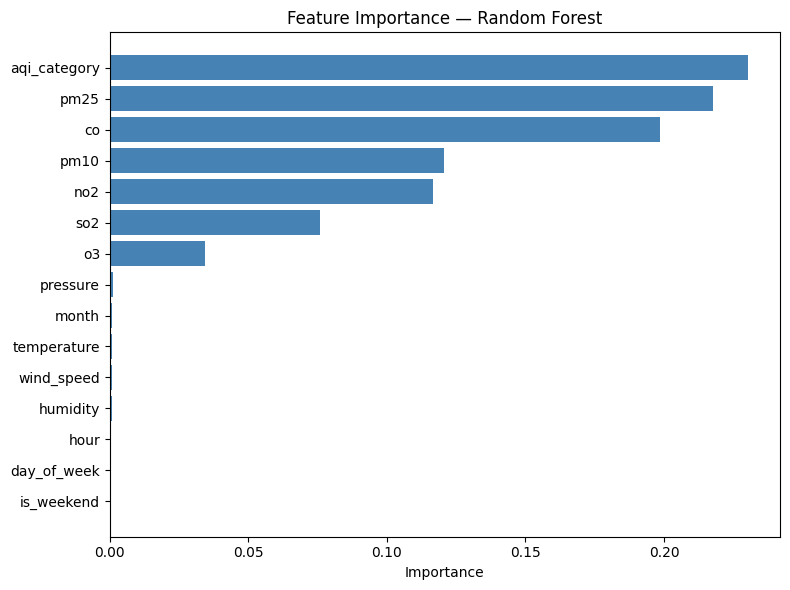

   Saved: feature_importance.png


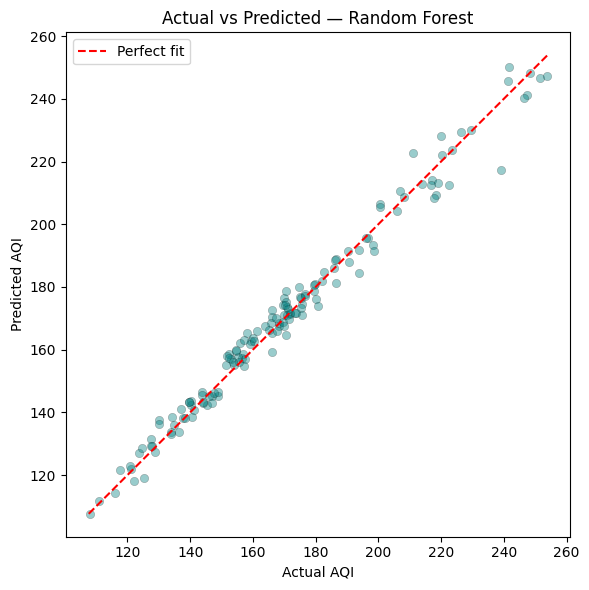

   Saved: actual_vs_predicted.png

💾 Saving model to Hopsworks Model Registry...


  0%|          | 0/6 [00:00<?, ?it/s]

Uploading /content/aqi_model.pkl: 0.000%|          | 0/3997057 elapsed<00:00 remaining<?

Model created, explore it at https://eu-west.cloud.hopsworks.ai:443/p/33060/models/aqi_predictor/1
✅ Model saved to registry as 'aqi_predictor'
   Metrics: {'rmse': np.float64(4.4511), 'mae': 3.3673, 'r2': 0.9814}

🎉 Training pipeline complete!



In [34]:
best_model = run_training()